In [8]:
# 2020 MEPS: merge Prescribed Medicines (HC-220A) with Full Year Consolidated (HC-224)

#Merge `h220a.xlsx` (Rx fill-level rows) with `H224.xlsx` (person-level traits) on **`DUPERSID`**.

In [9]:
import subprocess
import sys
from pathlib import Path

import pandas as pd

try:
    import python_calamine  # noqa: F401
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "python-calamine", "-q"])

EXCEL_ENGINE = "calamine"


def resolve_meps_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "data" / "MEPS" / "excels",
        cwd / "data" / "MEPS",
        cwd / "MEPS" / "excels",
        cwd / "MEPS",
        cwd,
        cwd.parent / "data" / "MEPS" / "excels",
        cwd.parent / "data" / "MEPS",
        cwd.parent.parent / "data" / "MEPS" / "excels",
        cwd.parent.parent / "data" / "MEPS",
    ]
    for d in candidates:
        if d.exists() and any(d.glob("h220a.xlsx")):
            return d
    return candidates[0]


MEPS_DIR = resolve_meps_dir()
print(f"MEPS directory: {MEPS_DIR}")

MEPS directory: /Users/friana/Medical Adherence/data/MEPS


In [10]:
# HC-220A (2020): Rx fill identifiers, drug info, therapeutics, and payment components.
# Fill-level payments use the 2020 calendar-year suffix (*20X) in h220a (not *23X).

H220A_COLS = [
    "DUPERSID",
    "RXRECIDX",
    "DRUGIDX",
    "LINKIDX",
    "RXNDC",
    "RXNAME",
    "RXDRGNAM",
    "TC1",
    "TC1S1",
    "TC1S1_1",
    "TC2",
    "TC3",
    "PURCHRD",
    "RXDAYSUP",
    "RXQUANTY",
    "RXSF20X",
    "RXXP20X",
    "RXMR20X",
    "RXMD20X",
    "RXPV20X",
    "RXOT20X",
    "RXFORM",
    "RXSTRENG",
    "RXSTRUNT",
]

h220a = pd.read_excel(
    MEPS_DIR / "h220a.xlsx",
    sheet_name="H220A",
    usecols=H220A_COLS,
    engine=EXCEL_ENGINE,
)

print(f"h220a shape: {h220a.shape}")
print(f"unique persons in h220a: {h220a['DUPERSID'].nunique():,}")
h220a.head()

h220a shape: (279755, 24)
unique persons in h220a: 15,743


,DUPERSID,DRUGIDX,RXRECIDX,LINKIDX,PURCHRD,RXNAME,RXDRGNAM,RXNDC,RXQUANTY,RXFORM,...,TC1S1,TC1S1_1,TC2,TC3,RXSF20X,RXMR20X,RXMD20X,RXPV20X,RXOT20X,RXXP20X
0,2320005101,2320005101001,2320005101001603001,2320005101001603,6,METFORMIN,METFORMIN,378718705,180.0,TABS,...,99,214,-1,-1,3.60,5.35,0.0,0.0,0.0,8.95
1,2320005101,2320005101001,2320005101001603002,2320005101001603,6,METFORMIN,METFORMIN,378718705,180.0,TABS,...,99,214,-1,-1,3.60,5.35,0.0,0.0,0.0,8.95
2,2320005101,2320005101001,2320005101001603003,2320005101001603,6,METFORMIN,METFORMIN,378718705,180.0,TABS,...,99,214,-1,-1,3.60,5.35,0.0,0.0,0.0,8.95
3,2320005102,2320005102001,2320005102001603001,2320005102001603,6,LOSARTAN POT,LOSARTAN,68180037703,180.0,TABS,...,56,-1,-1,-1,7.79,188.83,0.0,0.0,0.0,196.62
4,2320005102,2320005102001,2320005102001603002,2320005102001603,6,LOSARTAN POT,LOSARTAN,31722070110,180.0,TABS,...,56,-1,-1,-1,12.00,63.37,0.0,0.0,0.0,75.37


In [11]:
H224 = pd.read_excel(
    MEPS_DIR / "H224.xlsx",
    sheet_name="H224",
    engine=EXCEL_ENGINE,
)

# H224 is one row per person; h220a is one row per Rx fill (many rows per person)
merged_df = h220a.merge(H224, on="DUPERSID", how="left", validate="m:1")

print(f"H224 shape: {H224.shape}")
print(f"merged_df shape: {merged_df.shape}")
print(f"Rx rows without a matching person in H224: {merged_df['AGE20X'].isna().sum():,}")

merged_df.head()

H224 shape: (27805, 1451)
merged_df shape: (279755, 1474)
Rx rows without a matching person in H224: 0


,DUPERSID,DRUGIDX,RXRECIDX,LINKIDX,PURCHRD,RXNAME,RXDRGNAM,RXNDC,RXQUANTY,RXFORM,...,RXOSR20,RXPTR20,RXOTH20,PERWT20F,FAMWT20F,FAMWT20C,SAQWT20F,DIABW20F,VARSTR,VARPSU
0,2320005101,2320005101001,2320005101001603001,2320005101001603,6,METFORMIN,METFORMIN,378718705,180.0,TABS,...,0,0,0,8418.417067,10019.765809,10019.765809,0.0,0.0,2079,1
1,2320005101,2320005101001,2320005101001603002,2320005101001603,6,METFORMIN,METFORMIN,378718705,180.0,TABS,...,0,0,0,8418.417067,10019.765809,10019.765809,0.0,0.0,2079,1
2,2320005101,2320005101001,2320005101001603003,2320005101001603,6,METFORMIN,METFORMIN,378718705,180.0,TABS,...,0,0,0,8418.417067,10019.765809,10019.765809,0.0,0.0,2079,1
3,2320005102,2320005102001,2320005102001603001,2320005102001603,6,LOSARTAN POT,LOSARTAN,68180037703,180.0,TABS,...,0,0,0,5199.931866,10019.765809,10019.765809,0.0,0.0,2079,1
4,2320005102,2320005102001,2320005102001603002,2320005102001603,6,LOSARTAN POT,LOSARTAN,31722070110,180.0,TABS,...,0,0,0,5199.931866,10019.765809,10019.765809,0.0,0.0,2079,1


## Age distribution by sex

Histogram of ages in the **2020** MEPS Rx cohort, color-coded for males and females (`SEX`: 1 = Male, 2 = Female). One row per person (deduped on `DUPERSID`).

### Bin choices

A one-year-per-bar chart has too many bars to read easily. We use **10-year age groups**, plus a separate **Under 20** band:

| Bin | Ages included | Why |
|-----|---------------|-----|
| Under 20 | 0–19 | Keeps children/young adults separate from working-age adults |
| 20–29 | 20–29 | Standard decade band |
| 30–39 … 70–79 | 30–39, etc. | Same 10-year width for comparison across mid/older life |
| 80+ | 80–85 | MEPS top-codes age at 85, so this is the oldest open-ended group |

Boundaries use **left-inclusive, right-exclusive** intervals (`right=False`), so age 20 falls in **20–29**, not Under 20.

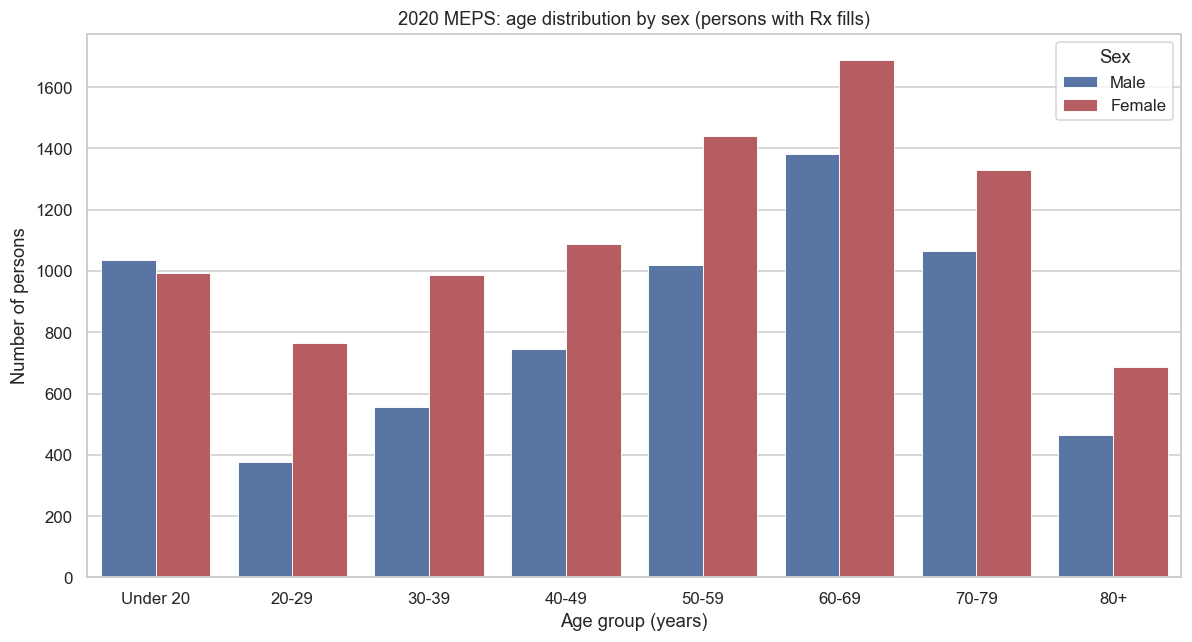

Sex,Female,Male,All
age_group,,,
Under 20,994,1037,2031
20-29,764,376,1140
30-39,988,556,1544
40-49,1088,746,1834
50-59,1440,1019,2459
60-69,1690,1382,3072
70-79,1330,1064,2394
80+,686,466,1152
All,8980,6646,15626


In [12]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

AGE_BIN_EDGES = [0, 20, 30, 40, 50, 60, 70, 80, 86]
AGE_BIN_LABELS = [
    "Under 20", "20-29", "30-39", "40-49",
    "50-59", "60-69", "70-79", "80+",
]

person_demo = (
    merged_df[["DUPERSID", "SEX", "AGE20X"]]
    .drop_duplicates("DUPERSID")
    .loc[lambda d: d["AGE20X"].between(0, 85)]
    .assign(
        Sex=lambda d: d["SEX"].map({1: "Male", 2: "Female"}),
        age_group=lambda d: pd.cut(
            d["AGE20X"],
            bins=AGE_BIN_EDGES,
            labels=AGE_BIN_LABELS,
            right=False,
        ),
    )
    .dropna(subset=["Sex", "age_group"])
)

palette = {"Male": "#4C72B0", "Female": "#C44E52"}

fig, ax = plt.subplots(figsize=(11, 6))
sns.countplot(
    data=person_demo,
    x="age_group",
    hue="Sex",
    order=AGE_BIN_LABELS,
    hue_order=["Male", "Female"],
    palette=palette,
    edgecolor="white",
    linewidth=0.6,
    ax=ax,
)

ax.set_title("2020 MEPS: age distribution by sex (persons with Rx fills)")
ax.set_xlabel("Age group (years)")
ax.set_ylabel("Number of persons")
ax.legend(title="Sex", frameon=True, loc="upper right")

plt.tight_layout()
plt.show()

pd.crosstab(person_demo["age_group"], person_demo["Sex"], margins=True)

## Therapeutic class columns (TC1, TC1S1, TC1S1_1, TC2, TC3)

Summary of **unique values** and data-quality flags (null / negative MEPS codes) at the **Rx fill** row level in `merged_df`. Segregation tables use the same age brackets as the histogram and person sex from **H224**.

In [13]:
import numpy as np
from IPython.display import display

TC_COLS = ["TC1", "TC1S1", "TC1S1_1", "TC2", "TC3"]

# Same age brackets as the histogram (run that cell first, or use these defaults)
if "AGE_BIN_EDGES" not in globals():
    AGE_BIN_EDGES = [0, 20, 30, 40, 50, 60, 70, 80, 86]
    AGE_BIN_LABELS = [
        "Under 20", "20-29", "30-39", "40-49",
        "50-59", "60-69", "70-79", "80+",
    ]

tc_df = merged_df[["DUPERSID", "SEX", "AGE20X"] + TC_COLS].copy()
tc_df["Sex"] = tc_df["SEX"].map({1: "Male", 2: "Female"})
tc_df["age_group"] = pd.cut(
    tc_df["AGE20X"],
    bins=AGE_BIN_EDGES,
    labels=AGE_BIN_LABELS,
    right=False,
)

# MEPS uses negative integers for missing / not applicable (e.g. -1, -15)
def tc_value_status(series: pd.Series) -> pd.Series:
    return np.select(
        [series.isna(), series < 0, series >= 0],
        ["Null / missing", "Negative (invalid)", "Valid (>= 0)"],
        default="Other",
    )


def negative_code_label(val):
    if pd.isna(val):
        return "Null"
    if val < 0:
        return str(int(val))
    return "Valid (>= 0)"


tc_unique_rows = []
for col in TC_COLS:
    s = tc_df[col]
    neg_counts = s[s < 0].value_counts().sort_index()
    neg_detail = ", ".join(f"{int(k)}: {v:,}" for k, v in neg_counts.items()) or "—"
    valid_unique = s[s >= 0].nunique(dropna=True)

    tc_unique_rows.append(
        {
            "column": col,
            "unique_values_all": s.nunique(dropna=False),
            "unique_values_valid_only": valid_unique,
            "null_count": int(s.isna().sum()),
            "negative_count": int((s < 0).sum()),
            "valid_count": int((s >= 0).sum()),
            "negative_codes (count)": neg_detail,
        }
    )

tc_unique_summary = pd.DataFrame(tc_unique_rows).set_index("column")
print("Unique values and data-quality flags per TC column (Rx fill rows):")
display(tc_unique_summary)

Unique values and data-quality flags per TC column (Rx fill rows):


,unique_values_all,unique_values_valid_only,null_count,negative_count,valid_count,negative_codes (count)
column,,,,,,
TC1,17,16,0,7106,272649,"-15: 7,106"
TC1S1,99,97,0,13316,266439,"-15: 6,210, -1: 7,106"
TC1S1_1,130,128,0,100821,178934,"-15: 3,095, -1: 97,726"
TC2,14,13,0,269417,10338,"-1: 269,417"
TC3,3,2,0,279227,528,"-1: 279,227"


In [14]:
print(f"Total Rx fill rows: {len(tc_df):,}")
print(f"Rows with missing Sex: {tc_df['Sex'].isna().sum():,}")
print(f"Rows with missing age_group: {tc_df['age_group'].isna().sum():,}")

rx_by_sex = tc_df["Sex"].value_counts(dropna=False).rename_axis("Sex").to_frame("rx_fill_rows")
rx_by_age = (
    tc_df["age_group"]
    .value_counts(dropna=False)
    .reindex(AGE_BIN_LABELS)
    .rename_axis("age_group")
    .to_frame("rx_fill_rows")
)

print("\nRx fills by sex:")
display(rx_by_sex)

print("\nRx fills by age bracket:")
display(rx_by_age)

print("\nRx fills by sex × age bracket:")
display(
    pd.crosstab(
        tc_df["age_group"],
        tc_df["Sex"],
        margins=True,
        dropna=False,
    ).reindex(AGE_BIN_LABELS + ["All"])
)

for col in TC_COLS:
    tmp = tc_df[["Sex", "age_group", col]].copy()
    tmp["value_status"] = tc_value_status(tmp[col])
    tmp["negative_code"] = tmp[col].apply(negative_code_label)

    print("=" * 72)
    print(f"{col} — value status by sex (Rx fill rows)")
    display(
        pd.crosstab(tmp["Sex"], tmp["value_status"], margins=True, dropna=False)
        .rename_axis(index="Sex", columns="value_status")
    )

    neg_only = tmp[tmp[col] < 0]
    if not neg_only.empty:
        print(f"{col} — negative codes by sex")
        display(
            pd.crosstab(neg_only["Sex"], neg_only["negative_code"], margins=True, dropna=False)
            .rename_axis(index="Sex", columns="negative_code")
        )

    print(f"{col} — value status by age bracket")
    display(
        pd.crosstab(tmp["age_group"], tmp["value_status"], margins=True, dropna=False)
        .reindex(AGE_BIN_LABELS + ["All"])
        .rename_axis(index="age_group", columns="value_status")
    )

    if not neg_only.empty:
        print(f"{col} — negative codes by age bracket")
        display(
            pd.crosstab(neg_only["age_group"], neg_only["negative_code"], margins=True, dropna=False)
            .reindex(AGE_BIN_LABELS + ["All"])
            .rename_axis(index="age_group", columns="negative_code")
        )

Total Rx fill rows: 279,755
Rows with missing Sex: 0
Rows with missing age_group: 1,724

Rx fills by sex:


,rx_fill_rows
Sex,
Female,165301
Male,114454



Rx fills by age bracket:


,rx_fill_rows
age_group,
Under 20,12219
20-29,8452
30-39,16918
40-49,27733
50-59,53352
60-69,73309
70-79,56067
80+,29981



Rx fills by sex × age bracket:


...

negative_code,-1,All
Sex,,
Female,164943,164943
Male,114284,114284
All,279227,279227


TC3 — value status by age bracket


value_status,Negative (invalid),Valid (>= 0),All
age_group,,,
Under 20,12219,0,12219
20-29,8451,1,8452
30-39,16887,31,16918
40-49,27693,40,27733
50-59,53209,143,53352
60-69,73146,163,73309
70-79,55979,88,56067
80+,29921,60,29981
All,279227,528,279755


TC3 — negative codes by age bracket


negative_code,-1,All
age_group,,
Under 20,12219,12219
20-29,8451,8451
30-39,16887,16887
40-49,27693,27693
50-59,53209,53209
60-69,73146,73146
70-79,55979,55979
80+,29921,29921
All,279227,279227


## Rows for a specific LINKIDX (2020)

Filter **2020** prescribed-medicine fills (`h220a` / `merged_df`) where `LINKIDX` matches the target value. Each row is one Rx fill, with person-level traits from `H224` merged in.

In [15]:
LINKIDX_TARGET = 2320005101001603

linkidx_mask = (
    pd.to_numeric(merged_df["LINKIDX"], errors="coerce").astype("Int64") == LINKIDX_TARGET
)
linkidx_rows = merged_df.loc[linkidx_mask].copy()

print(f"2020 rows with LINKIDX == {LINKIDX_TARGET}: {len(linkidx_rows):,}")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)

linkidx_rows

2020 rows with LINKIDX == 2320005101001603: 3


,DUPERSID,DRUGIDX,RXRECIDX,LINKIDX,PURCHRD,RXNAME,RXDRGNAM,RXNDC,RXQUANTY,RXFORM,RXSTRENG,RXSTRUNT,RXDAYSUP,TC1,TC1S1,TC1S1_1,TC2,TC3,RXSF20X,RXMR20X,RXMD20X,RXPV20X,RXOT20X,RXXP20X,DUID,PID,PANEL,FAMID31,FAMID42,FAMID53,FAMID20,FAMIDYR,CPSFAMID,FCSZ1231,FCRP1231,RULETR31,RULETR42,RULETR53,RULETR20,RUSIZE31,RUSIZE42,RUSIZE53,RUSIZE20,RUCLAS31,RUCLAS42,RUCLAS53,RUCLAS20,FAMSZE31,FAMSZE42,FAMSZE53,FAMSZE20,FMRS1231,FAMS1231,FAMSZEYR,FAMRFPYR,REGION31,REGION42,REGION53,REGION20,REFPRS31,REFPRS42,REFPRS53,REFPRS20,RESP31,RESP42,RESP53,RESP20,PROXY31,PROXY42,PROXY53,PROXY20,INTVLANG,BEGRFM31,BEGRFY31,ENDRFM31,ENDRFY31,BEGRFM42,BEGRFY42,ENDRFM42,ENDRFY42,BEGRFM53,BEGRFY53,ENDRFM53,ENDRFY53,ENDRFM20,ENDRFY20,KEYNESS,INSCOP31,INSCOP42,INSCOP53,INSCOP20,INSC1231,INSCOPE,ELGRND31,ELGRND42,ELGRND53,ELGRND20,PSTATS31,PSTATS42,PSTATS53,RURSLT31,RURSLT42,RURSLT53,AGE31X,AGE42X,AGE53X,AGE20X,AGELAST,DOBMM,DOBYY,SEX,RACEV1X,RACEV2X,RACEAX,RACEBX,RACEWX,RACETHX,HISPANX,HISPNCAT,MARRY31X,MARRY42X,MARRY53X,MARRY20X,SPOUID31,SPOUID42,SPOUID53,SPOUID20,SPOUIN31,SPOUIN42,SPOUIN53,SPOUIN20,EDUCYR,HIDEG,FTSTU31X,FTSTU42X,FTSTU53X,FTSTU20X,ACTDTY31,ACTDTY42,ACTDTY53,REFRL31X,REFRL42X,REFRL53X,REFRL20X,OTHLGSPK,WHTLGSPK,HWELLSPK,BORNUSA,YRSINUS,MOPID31X,MOPID42X,MOPID53X,DAPID31X,DAPID42X,DAPID53X,RTHLTH31,RTHLTH42,RTHLTH53,MNHLTH31,MNHLTH42,MNHLTH53,HIBPDX,HIBPAGED,BPMLDX,CHDDX,CHDAGED,ANGIDX,ANGIAGED,MIDX,MIAGED,OHRTDX,OHRTAGED,OHRTTYPE,STRKDX,STRKAGED,EMPHDX,EMPHAGED,CHBRON31,CHBRON53,CHOLDX,CHOLAGED,CANCERDX,CABLADDR,CABLOOD,CABREAST,CACERVIX,CACOLON,CALUNG,CALYMPH,CAMELANO,CAOTHER,CAPROSTA,CASKINNM,CASKINDK,CAUTERUS,DIABDX_M18,DIABAGED,JTPAIN31_M18,JTPAIN53_M18,ARTHDX,ARTHTYPE,ARTHAGED,ASTHDX,ASTHAGED,ASSTIL31,ASSTIL53,ASATAK31,ASATAK53,ASTHEP31,ASTHEP53,ASACUT31,ASACUT53,ASMRCN31,ASMRCN53,ASPREV31,ASPREV53,ASDALY31,ASDALY53,ASPKFL31,ASPKFL53,ASEVFL31,ASEVFL53,ASWNFL31,ASWNFL53,ADHDADDX,ADHDAGED,IADLHP31,IADLHP53,ADLHLP31,ADLHLP53,AIDHLP31,AIDHLP53,WLKLIM31,WLKLIM53,LFTDIF31,LFTDIF53,STPDIF31,STPDIF53,WLKDIF31,WLKDIF53,MILDIF31,MILDIF53,STNDIF31,STNDIF53,BENDIF31,BENDIF53,RCHDIF31,RCHDIF53,FNGRDF31,FNGRDF53,ACTLIM31,ACTLIM53,WRKLIM31,WRKLIM53,HSELIM31,HSELIM53,SCHLIM31,SCHLIM53,UNABLE31,UNABLE53,SOCLIM31,SOCLIM53,COGLIM31,COGLIM53,DFHEAR42,DFSEE42,DFCOG42,DFWLKC42,DFDRSB42,DFERND42,ANYLMI20,CHPMED42,CHPMHB42,CHPMCN42,CHSERV42,CHSRHB42,CHSRCN42,CHLIMI42,CHLIHB42,CHLICO42,CHTHER42,CHTHHB42,CHTHCO42,CHCOUN42,CHEMPB42,CSHCN42,MESHGT42,WHNHGT42,MESWGT42,WHNWGT42,CHBMIX42,MESVIS42,EATHLT42,WHNEAT42,PHYSCL42,WHNPHY42,SAFEST42,WHNSAF42,BOOST42,WHNBST42,LAPBLT42,WHNLAP42,HELMET42,WHNHEL42,NOSMOK42,WHNSMK42,TIMALN42,LSTETH53,PHYEXE53,OFTSMK53,SAQELIG,ADPROX42,ADSEX42,ADAGE42,ADGENH42,ADDAYA42,ADCLIM42,ADACLS42,ADWKLM42,ADEMLS42,ADMWCF42,ADPAIN42,ADPCFL42,ADENGY42,ADPRST42,ADSOCA42,VPCS42,VMCS42,VRFLAG42,ADNERV42,ADHOPE42,ADREST42,ADSAD42,ADEFRT42,ADWRTH42,K6SUM42,ADINTR42,ADDPRS42,PHQ242,ADSLEEP42,ADKALC42,ADNUMDRK42,ADRNK542,ADRNK442,ADOFTALC42,ADSTAL42,ADMNTRT42,ADRATETRT42,ADTRTHLP42,ADTRTPD42,ADPROBTRT42,ADUNABTRT42,ADRELTRT42,ADSCHTRT42,ADGRPTRT42,ADONLTRT42,ADPHONTRT42,ADAPPTRT42,ADTRTEXP42,ADBRTC42,ADMDVT42,ADFLST42,ADWGHD42,ADWTAD42,ADTBAC42,ADOFTB42,ADQTTB42,ADQTMD42,ADQTHP42,ADMOOD42,ADBPCK42,ADCHLC42,ADPNEU42,ADSHNG42,ADNOAP42,ADDSCU42,ADCOLN42,ADCLNS42,ADSGMD42,ADBLDS42,ADPROS42,ADPSAG42,ADUTRM42,ADPAP42,ADPAPG42,ADOSTP42,ADBNDN42,ADBRST42,ADMMGR42,ADCMPM42,ADCMPY42,ADLANG42,ADBMI42,DCSELIG,DSDIA53,DSA1C53,DSFT2153,DSFT2053,DSFT1953,DSFB1953,DSFTNV53,DSEY2153,DSEY2053,DSEY1953,DSEB1953,DSEYNV53,DSCH2153,DSCH2053,DSCH1953,DSCB1953,DSCHNV53,DSFL2153,DSFL2053,DSFL1953,DSVB1953,DSFLNV53,DSKIDN53,DSEYPR53,DSDIET53,DSMED53,DSINSU53,DSCPCP53,DSCNPC53,DSCPHN53,DSCINT53,DSCGRP53,DSCONF53,DSPRX53,DDNWRK20,OTHDYS20,OTHNDD20,ACCELI42,HAVEUS42,PRACTP42,YNOUSC42_M18,PROVTY42_M18,PLCTYP42,TMTKUS42,TYPEPE42,LOCATN42,HSPLAP42,WHITPR42,BLCKPR42,ASIANP42,NATAMP42,PACISP42,OTHRCP42,GENDRP42,PHNREG42,OFFHOU42,AFTHOU42,TREATM42,DECIDE42,EXPLOP42,PRVSPK42,DLAYCA42,AFR

In [16]:
df_medical_conditions = pd.read_excel(MEPS_DIR / "h220if1.xlsx")
#df_medical_conditions.head()
pd.set_option('display.max_columns', None)
df_medical_conditions.head()

,DUPERSID,CONDIDX,EVNTIDX,CLNKIDX,EVENTYPE,PANEL
0,2320005101,2320005101001,2320005101001603,23200051010012320005101001603,8,23
1,2320005102,2320005102001,2320005102001603,23200051020012320005102001603,8,23
2,2320005102,2320005102001,2320005102002603,23200051020012320005102002603,8,23
3,2320005102,2320005102004,2320005102001603,23200051020042320005102001603,8,23
4,2320005102,2320005102004,2320005102003603,23200051020042320005102003603,8,23


In [17]:
merge_on_linkidx = pd.merge(merged_df,df_medical_conditions, how="inner", left_on="LINKIDX", right_on  ="EVNTIDX")
pd.set_option('display.max_columns', None)

merge_on_linkidx.head()

,DUPERSID_x,DRUGIDX,RXRECIDX,LINKIDX,PURCHRD,RXNAME,RXDRGNAM,RXNDC,RXQUANTY,RXFORM,RXSTRENG,RXSTRUNT,RXDAYSUP,TC1,TC1S1,TC1S1_1,TC2,TC3,RXSF20X,RXMR20X,RXMD20X,RXPV20X,RXOT20X,RXXP20X,DUID,PID,PANEL_x,FAMID31,FAMID42,FAMID53,FAMID20,FAMIDYR,CPSFAMID,FCSZ1231,FCRP1231,RULETR31,RULETR42,RULETR53,RULETR20,RUSIZE31,RUSIZE42,RUSIZE53,RUSIZE20,RUCLAS31,RUCLAS42,RUCLAS53,RUCLAS20,FAMSZE31,FAMSZE42,FAMSZE53,FAMSZE20,FMRS1231,FAMS1231,FAMSZEYR,FAMRFPYR,REGION31,REGION42,REGION53,REGION20,REFPRS31,REFPRS42,REFPRS53,REFPRS20,RESP31,RESP42,RESP53,RESP20,PROXY31,PROXY42,PROXY53,PROXY20,INTVLANG,BEGRFM31,BEGRFY31,ENDRFM31,ENDRFY31,BEGRFM42,BEGRFY42,ENDRFM42,ENDRFY42,BEGRFM53,BEGRFY53,ENDRFM53,ENDRFY53,ENDRFM20,ENDRFY20,KEYNESS,INSCOP31,INSCOP42,INSCOP53,INSCOP20,INSC1231,INSCOPE,ELGRND31,ELGRND42,ELGRND53,ELGRND20,PSTATS31,PSTATS42,PSTATS53,RURSLT31,RURSLT42,RURSLT53,AGE31X,AGE42X,AGE53X,AGE20X,AGELAST,DOBMM,DOBYY,SEX,RACEV1X,RACEV2X,RACEAX,RACEBX,RACEWX,RACETHX,HISPANX,HISPNCAT,MARRY31X,MARRY42X,MARRY53X,MARRY20X,SPOUID31,SPOUID42,SPOUID53,SPOUID20,SPOUIN31,SPOUIN42,SPOUIN53,SPOUIN20,EDUCYR,HIDEG,FTSTU31X,FTSTU42X,FTSTU53X,FTSTU20X,ACTDTY31,ACTDTY42,ACTDTY53,REFRL31X,REFRL42X,REFRL53X,REFRL20X,OTHLGSPK,WHTLGSPK,HWELLSPK,BORNUSA,YRSINUS,MOPID31X,MOPID42X,MOPID53X,DAPID31X,DAPID42X,DAPID53X,RTHLTH31,RTHLTH42,RTHLTH53,MNHLTH31,MNHLTH42,MNHLTH53,HIBPDX,HIBPAGED,BPMLDX,CHDDX,CHDAGED,ANGIDX,ANGIAGED,MIDX,MIAGED,OHRTDX,OHRTAGED,OHRTTYPE,STRKDX,STRKAGED,EMPHDX,EMPHAGED,CHBRON31,CHBRON53,CHOLDX,CHOLAGED,CANCERDX,CABLADDR,CABLOOD,CABREAST,CACERVIX,CACOLON,CALUNG,CALYMPH,CAMELANO,CAOTHER,CAPROSTA,CASKINNM,CASKINDK,CAUTERUS,DIABDX_M18,DIABAGED,JTPAIN31_M18,JTPAIN53_M18,ARTHDX,ARTHTYPE,ARTHAGED,ASTHDX,ASTHAGED,ASSTIL31,ASSTIL53,ASATAK31,ASATAK53,ASTHEP31,ASTHEP53,ASACUT31,ASACUT53,ASMRCN31,ASMRCN53,ASPREV31,ASPREV53,ASDALY31,ASDALY53,ASPKFL31,ASPKFL53,ASEVFL31,ASEVFL53,ASWNFL31,ASWNFL53,ADHDADDX,ADHDAGED,IADLHP31,IADLHP53,ADLHLP31,ADLHLP53,AIDHLP31,AIDHLP53,WLKLIM31,WLKLIM53,LFTDIF31,LFTDIF53,STPDIF31,STPDIF53,WLKDIF31,WLKDIF53,MILDIF31,MILDIF53,STNDIF31,STNDIF53,BENDIF31,BENDIF53,RCHDIF31,RCHDIF53,FNGRDF31,FNGRDF53,ACTLIM31,ACTLIM53,WRKLIM31,WRKLIM53,HSELIM31,HSELIM53,SCHLIM31,SCHLIM53,UNABLE31,UNABLE53,SOCLIM31,SOCLIM53,COGLIM31,COGLIM53,DFHEAR42,DFSEE42,DFCOG42,DFWLKC42,DFDRSB42,DFERND42,ANYLMI20,CHPMED42,CHPMHB42,CHPMCN42,CHSERV42,CHSRHB42,CHSRCN42,CHLIMI42,CHLIHB42,CHLICO42,CHTHER42,CHTHHB42,CHTHCO42,CHCOUN42,CHEMPB42,CSHCN42,MESHGT42,WHNHGT42,MESWGT42,WHNWGT42,CHBMIX42,MESVIS42,EATHLT42,WHNEAT42,PHYSCL42,WHNPHY42,SAFEST42,WHNSAF42,BOOST42,WHNBST42,LAPBLT42,WHNLAP42,HELMET42,WHNHEL42,NOSMOK42,WHNSMK42,TIMALN42,LSTETH53,PHYEXE53,OFTSMK53,SAQELIG,ADPROX42,ADSEX42,ADAGE42,ADGENH42,ADDAYA42,ADCLIM42,ADACLS42,ADWKLM42,ADEMLS42,ADMWCF42,ADPAIN42,ADPCFL42,ADENGY42,ADPRST42,ADSOCA42,VPCS42,VMCS42,VRFLAG42,ADNERV42,ADHOPE42,ADREST42,ADSAD42,ADEFRT42,ADWRTH42,K6SUM42,ADINTR42,ADDPRS42,PHQ242,ADSLEEP42,ADKALC42,ADNUMDRK42,ADRNK542,ADRNK442,ADOFTALC42,ADSTAL42,ADMNTRT42,ADRATETRT42,ADTRTHLP42,ADTRTPD42,ADPROBTRT42,ADUNABTRT42,ADRELTRT42,ADSCHTRT42,ADGRPTRT42,ADONLTRT42,ADPHONTRT42,ADAPPTRT42,ADTRTEXP42,ADBRTC42,ADMDVT42,ADFLST42,ADWGHD42,ADWTAD42,ADTBAC42,ADOFTB42,ADQTTB42,ADQTMD42,ADQTHP42,ADMOOD42,ADBPCK42,ADCHLC42,ADPNEU42,ADSHNG42,ADNOAP42,ADDSCU42,ADCOLN42,ADCLNS42,ADSGMD42,ADBLDS42,ADPROS42,ADPSAG42,ADUTRM42,ADPAP42,ADPAPG42,ADOSTP42,ADBNDN42,ADBRST42,ADMMGR42,ADCMPM42,ADCMPY42,ADLANG42,ADBMI42,DCSELIG,DSDIA53,DSA1C53,DSFT2153,DSFT2053,DSFT1953,DSFB1953,DSFTNV53,DSEY2153,DSEY2053,DSEY1953,DSEB1953,DSEYNV53,DSCH2153,DSCH2053,DSCH1953,DSCB1953,DSCHNV53,DSFL2153,DSFL2053,DSFL1953,DSVB1953,DSFLNV53,DSKIDN53,DSEYPR53,DSDIET53,DSMED53,DSINSU53,DSCPCP53,DSCNPC53,DSCPHN53,DSCINT53,DSCGRP53,DSCONF53,DSPRX53,DDNWRK20,OTHDYS20,OTHNDD20,ACCELI42,HAVEUS42,PRACTP42,YNOUSC42_M18,PROVTY42_M18,PLCTYP42,TMTKUS42,TYPEPE42,LOCATN42,HSPLAP42,WHITPR42,BLCKPR42,ASIANP42,NATAMP42,PACISP42,OTHRCP42,GENDRP42,PHNREG42,OFFHOU42,AFTHOU42,TREATM42,DECIDE42,EXPLOP42,PRVSPK42,DLAYCA42

In [18]:
col_x = merge_on_linkidx.columns.tolist()
for col in col_x:
    if(col.endswith("_y")):
        merge_on_linkidx.drop(columns=[col], inplace=True)
    elif(col.endswith("_x")):
        merge_on_linkidx.rename(columns={col: col[:-2]}, inplace=True)

merge_on_linkidx.head()

,DUPERSID,DRUGIDX,RXRECIDX,LINKIDX,PURCHRD,RXNAME,RXDRGNAM,RXNDC,RXQUANTY,RXFORM,RXSTRENG,RXSTRUNT,RXDAYSUP,TC1,TC1S1,TC1S1_1,TC2,TC3,RXSF20X,RXMR20X,RXMD20X,RXPV20X,RXOT20X,RXXP20X,DUID,PID,PANEL,FAMID31,FAMID42,FAMID53,FAMID20,FAMIDYR,CPSFAMID,FCSZ1231,FCRP1231,RULETR31,RULETR42,RULETR53,RULETR20,RUSIZE31,RUSIZE42,RUSIZE53,RUSIZE20,RUCLAS31,RUCLAS42,RUCLAS53,RUCLAS20,FAMSZE31,FAMSZE42,FAMSZE53,FAMSZE20,FMRS1231,FAMS1231,FAMSZEYR,FAMRFPYR,REGION31,REGION42,REGION53,REGION20,REFPRS31,REFPRS42,REFPRS53,REFPRS20,RESP31,RESP42,RESP53,RESP20,PROXY31,PROXY42,PROXY53,PROXY20,INTVLANG,BEGRFM31,BEGRFY31,ENDRFM31,ENDRFY31,BEGRFM42,BEGRFY42,ENDRFM42,ENDRFY42,BEGRFM53,BEGRFY53,ENDRFM53,ENDRFY53,ENDRFM20,ENDRFY20,KEYNESS,INSCOP31,INSCOP42,INSCOP53,INSCOP20,INSC1231,INSCOPE,ELGRND31,ELGRND42,ELGRND53,ELGRND20,PSTATS31,PSTATS42,PSTATS53,RURSLT31,RURSLT42,RURSLT53,AGE31X,AGE42X,AGE53X,AGE20X,AGELAST,DOBMM,DOBYY,SEX,RACEV1X,RACEV2X,RACEAX,RACEBX,RACEWX,RACETHX,HISPANX,HISPNCAT,MARRY31X,MARRY42X,MARRY53X,MARRY20X,SPOUID31,SPOUID42,SPOUID53,SPOUID20,SPOUIN31,SPOUIN42,SPOUIN53,SPOUIN20,EDUCYR,HIDEG,FTSTU31X,FTSTU42X,FTSTU53X,FTSTU20X,ACTDTY31,ACTDTY42,ACTDTY53,REFRL31X,REFRL42X,REFRL53X,REFRL20X,OTHLGSPK,WHTLGSPK,HWELLSPK,BORNUSA,YRSINUS,MOPID31X,MOPID42X,MOPID53X,DAPID31X,DAPID42X,DAPID53X,RTHLTH31,RTHLTH42,RTHLTH53,MNHLTH31,MNHLTH42,MNHLTH53,HIBPDX,HIBPAGED,BPMLDX,CHDDX,CHDAGED,ANGIDX,ANGIAGED,MIDX,MIAGED,OHRTDX,OHRTAGED,OHRTTYPE,STRKDX,STRKAGED,EMPHDX,EMPHAGED,CHBRON31,CHBRON53,CHOLDX,CHOLAGED,CANCERDX,CABLADDR,CABLOOD,CABREAST,CACERVIX,CACOLON,CALUNG,CALYMPH,CAMELANO,CAOTHER,CAPROSTA,CASKINNM,CASKINDK,CAUTERUS,DIABDX_M18,DIABAGED,JTPAIN31_M18,JTPAIN53_M18,ARTHDX,ARTHTYPE,ARTHAGED,ASTHDX,ASTHAGED,ASSTIL31,ASSTIL53,ASATAK31,ASATAK53,ASTHEP31,ASTHEP53,ASACUT31,ASACUT53,ASMRCN31,ASMRCN53,ASPREV31,ASPREV53,ASDALY31,ASDALY53,ASPKFL31,ASPKFL53,ASEVFL31,ASEVFL53,ASWNFL31,ASWNFL53,ADHDADDX,ADHDAGED,IADLHP31,IADLHP53,ADLHLP31,ADLHLP53,AIDHLP31,AIDHLP53,WLKLIM31,WLKLIM53,LFTDIF31,LFTDIF53,STPDIF31,STPDIF53,WLKDIF31,WLKDIF53,MILDIF31,MILDIF53,STNDIF31,STNDIF53,BENDIF31,BENDIF53,RCHDIF31,RCHDIF53,FNGRDF31,FNGRDF53,ACTLIM31,ACTLIM53,WRKLIM31,WRKLIM53,HSELIM31,HSELIM53,SCHLIM31,SCHLIM53,UNABLE31,UNABLE53,SOCLIM31,SOCLIM53,COGLIM31,COGLIM53,DFHEAR42,DFSEE42,DFCOG42,DFWLKC42,DFDRSB42,DFERND42,ANYLMI20,CHPMED42,CHPMHB42,CHPMCN42,CHSERV42,CHSRHB42,CHSRCN42,CHLIMI42,CHLIHB42,CHLICO42,CHTHER42,CHTHHB42,CHTHCO42,CHCOUN42,CHEMPB42,CSHCN42,MESHGT42,WHNHGT42,MESWGT42,WHNWGT42,CHBMIX42,MESVIS42,EATHLT42,WHNEAT42,PHYSCL42,WHNPHY42,SAFEST42,WHNSAF42,BOOST42,WHNBST42,LAPBLT42,WHNLAP42,HELMET42,WHNHEL42,NOSMOK42,WHNSMK42,TIMALN42,LSTETH53,PHYEXE53,OFTSMK53,SAQELIG,ADPROX42,ADSEX42,ADAGE42,ADGENH42,ADDAYA42,ADCLIM42,ADACLS42,ADWKLM42,ADEMLS42,ADMWCF42,ADPAIN42,ADPCFL42,ADENGY42,ADPRST42,ADSOCA42,VPCS42,VMCS42,VRFLAG42,ADNERV42,ADHOPE42,ADREST42,ADSAD42,ADEFRT42,ADWRTH42,K6SUM42,ADINTR42,ADDPRS42,PHQ242,ADSLEEP42,ADKALC42,ADNUMDRK42,ADRNK542,ADRNK442,ADOFTALC42,ADSTAL42,ADMNTRT42,ADRATETRT42,ADTRTHLP42,ADTRTPD42,ADPROBTRT42,ADUNABTRT42,ADRELTRT42,ADSCHTRT42,ADGRPTRT42,ADONLTRT42,ADPHONTRT42,ADAPPTRT42,ADTRTEXP42,ADBRTC42,ADMDVT42,ADFLST42,ADWGHD42,ADWTAD42,ADTBAC42,ADOFTB42,ADQTTB42,ADQTMD42,ADQTHP42,ADMOOD42,ADBPCK42,ADCHLC42,ADPNEU42,ADSHNG42,ADNOAP42,ADDSCU42,ADCOLN42,ADCLNS42,ADSGMD42,ADBLDS42,ADPROS42,ADPSAG42,ADUTRM42,ADPAP42,ADPAPG42,ADOSTP42,ADBNDN42,ADBRST42,ADMMGR42,ADCMPM42,ADCMPY42,ADLANG42,ADBMI42,DCSELIG,DSDIA53,DSA1C53,DSFT2153,DSFT2053,DSFT1953,DSFB1953,DSFTNV53,DSEY2153,DSEY2053,DSEY1953,DSEB1953,DSEYNV53,DSCH2153,DSCH2053,DSCH1953,DSCB1953,DSCHNV53,DSFL2153,DSFL2053,DSFL1953,DSVB1953,DSFLNV53,DSKIDN53,DSEYPR53,DSDIET53,DSMED53,DSINSU53,DSCPCP53,DSCNPC53,DSCPHN53,DSCINT53,DSCGRP53,DSCONF53,DSPRX53,DDNWRK20,OTHDYS20,OTHNDD20,ACCELI42,HAVEUS42,PRACTP42,YNOUSC42_M18,PROVTY42_M18,PLCTYP42,TMTKUS42,TYPEPE42,LOCATN42,HSPLAP42,WHITPR42,BLCKPR42,ASIANP42,NATAMP42,PACISP42,OTHRCP42,GENDRP42,PHNREG42,OFFHOU42,AFTHOU42,TREATM42,DECIDE42,EXPLOP42,PRVSPK42,DLAYCA42,AFR

In [29]:
df2 = pd.read_excel(MEPS_DIR / "h222.xlsx")
pd.set_option('display.max_columns', None)
df2.head()

,DUID,PID,DUPERSID,CONDN,CONDIDX,PANEL,CONDRN,AGEDIAG,CRND1,CRND2,CRND3,CRND4,CRND5,CRND6,CRND7,INJURY,ACCDNWRK,ICD10CDX,CCSR1X,CCSR2X,CCSR3X,HHNUM,IPNUM,OPNUM,OBNUM,ERNUM,RXNUM,PERWT20F,VARSTR,VARPSU
0,2320005,101,2320005101,1,2320005101001,23,4,-1,-1,-1,-1,-1,-1,1,0,2,-1,-15,-15,-1,-1,0,0,0,0,0,1,8418.417067,2079,1
1,2320005,102,2320005102,1,2320005102001,23,1,71,-1,-1,-1,-1,-1,1,0,2,-1,I10,CIR007,-1,-1,0,0,0,0,0,2,5199.931866,2079,1
2,2320005,102,2320005102,4,2320005102004,23,2,-1,-1,-1,-1,-1,-1,1,0,2,-1,Z13,FAC003,-1,-1,0,0,0,0,0,2,5199.931866,2079,1
3,2320006,102,2320006102,8,2320006102008,23,7,-1,-1,-1,-1,-1,-1,0,1,1,2,Z04,FAC003,-1,-1,0,0,0,0,1,0,2216.008686,2028,1
4,2320006,103,2320006103,2,2320006103002,23,6,-1,-1,-1,-1,-1,-1,1,0,2,-1,R55,SYM001,-1,-1,0,0,0,0,1,0,4157.285889,2028,1


In [30]:
complete_df_2020 = pd.merge( merge_on_linkidx,df2, how="inner", on="CONDIDX")
pd.set_option('display.max_columns', None)

complete_df_2020.head()

,DUPERSID_x,DRUGIDX,RXRECIDX,LINKIDX,PURCHRD,RXNAME,RXDRGNAM,RXNDC,RXQUANTY,RXFORM,RXSTRENG,RXSTRUNT,RXDAYSUP,TC1,TC1S1,TC1S1_1,TC2,TC3,RXSF20X,RXMR20X,RXMD20X,RXPV20X,RXOT20X,RXXP20X,DUID_x,PID_x,PANEL_x,FAMID31,FAMID42,FAMID53,FAMID20,FAMIDYR,CPSFAMID,FCSZ1231,FCRP1231,RULETR31,RULETR42,RULETR53,RULETR20,RUSIZE31,RUSIZE42,RUSIZE53,RUSIZE20,RUCLAS31,RUCLAS42,RUCLAS53,RUCLAS20,FAMSZE31,FAMSZE42,FAMSZE53,FAMSZE20,FMRS1231,FAMS1231,FAMSZEYR,FAMRFPYR,REGION31,REGION42,REGION53,REGION20,REFPRS31,REFPRS42,REFPRS53,REFPRS20,RESP31,RESP42,RESP53,RESP20,PROXY31,PROXY42,PROXY53,PROXY20,INTVLANG,BEGRFM31,BEGRFY31,ENDRFM31,ENDRFY31,BEGRFM42,BEGRFY42,ENDRFM42,ENDRFY42,BEGRFM53,BEGRFY53,ENDRFM53,ENDRFY53,ENDRFM20,ENDRFY20,KEYNESS,INSCOP31,INSCOP42,INSCOP53,INSCOP20,INSC1231,INSCOPE,ELGRND31,ELGRND42,ELGRND53,ELGRND20,PSTATS31,PSTATS42,PSTATS53,RURSLT31,RURSLT42,RURSLT53,AGE31X,AGE42X,AGE53X,AGE20X,AGELAST,DOBMM,DOBYY,SEX,RACEV1X,RACEV2X,RACEAX,RACEBX,RACEWX,RACETHX,HISPANX,HISPNCAT,MARRY31X,MARRY42X,MARRY53X,MARRY20X,SPOUID31,SPOUID42,SPOUID53,SPOUID20,SPOUIN31,SPOUIN42,SPOUIN53,SPOUIN20,EDUCYR,HIDEG,FTSTU31X,FTSTU42X,FTSTU53X,FTSTU20X,ACTDTY31,ACTDTY42,ACTDTY53,REFRL31X,REFRL42X,REFRL53X,REFRL20X,OTHLGSPK,WHTLGSPK,HWELLSPK,BORNUSA,YRSINUS,MOPID31X,MOPID42X,MOPID53X,DAPID31X,DAPID42X,DAPID53X,RTHLTH31,RTHLTH42,RTHLTH53,MNHLTH31,MNHLTH42,MNHLTH53,HIBPDX,HIBPAGED,BPMLDX,CHDDX,CHDAGED,ANGIDX,ANGIAGED,MIDX,MIAGED,OHRTDX,OHRTAGED,OHRTTYPE,STRKDX,STRKAGED,EMPHDX,EMPHAGED,CHBRON31,CHBRON53,CHOLDX,CHOLAGED,CANCERDX,CABLADDR,CABLOOD,CABREAST,CACERVIX,CACOLON,CALUNG,CALYMPH,CAMELANO,CAOTHER,CAPROSTA,CASKINNM,CASKINDK,CAUTERUS,DIABDX_M18,DIABAGED,JTPAIN31_M18,JTPAIN53_M18,ARTHDX,ARTHTYPE,ARTHAGED,ASTHDX,ASTHAGED,ASSTIL31,ASSTIL53,ASATAK31,ASATAK53,ASTHEP31,ASTHEP53,ASACUT31,ASACUT53,ASMRCN31,ASMRCN53,ASPREV31,ASPREV53,ASDALY31,ASDALY53,ASPKFL31,ASPKFL53,ASEVFL31,ASEVFL53,ASWNFL31,ASWNFL53,ADHDADDX,ADHDAGED,IADLHP31,IADLHP53,ADLHLP31,ADLHLP53,AIDHLP31,AIDHLP53,WLKLIM31,WLKLIM53,LFTDIF31,LFTDIF53,STPDIF31,STPDIF53,WLKDIF31,WLKDIF53,MILDIF31,MILDIF53,STNDIF31,STNDIF53,BENDIF31,BENDIF53,RCHDIF31,RCHDIF53,FNGRDF31,FNGRDF53,ACTLIM31,ACTLIM53,WRKLIM31,WRKLIM53,HSELIM31,HSELIM53,SCHLIM31,SCHLIM53,UNABLE31,UNABLE53,SOCLIM31,SOCLIM53,COGLIM31,COGLIM53,DFHEAR42,DFSEE42,DFCOG42,DFWLKC42,DFDRSB42,DFERND42,ANYLMI20,CHPMED42,CHPMHB42,CHPMCN42,CHSERV42,CHSRHB42,CHSRCN42,CHLIMI42,CHLIHB42,CHLICO42,CHTHER42,CHTHHB42,CHTHCO42,CHCOUN42,CHEMPB42,CSHCN42,MESHGT42,WHNHGT42,MESWGT42,WHNWGT42,CHBMIX42,MESVIS42,EATHLT42,WHNEAT42,PHYSCL42,WHNPHY42,SAFEST42,WHNSAF42,BOOST42,WHNBST42,LAPBLT42,WHNLAP42,HELMET42,WHNHEL42,NOSMOK42,WHNSMK42,TIMALN42,LSTETH53,PHYEXE53,OFTSMK53,SAQELIG,ADPROX42,ADSEX42,ADAGE42,ADGENH42,ADDAYA42,ADCLIM42,ADACLS42,ADWKLM42,ADEMLS42,ADMWCF42,ADPAIN42,ADPCFL42,ADENGY42,ADPRST42,ADSOCA42,VPCS42,VMCS42,VRFLAG42,ADNERV42,ADHOPE42,ADREST42,ADSAD42,ADEFRT42,ADWRTH42,K6SUM42,ADINTR42,ADDPRS42,PHQ242,ADSLEEP42,ADKALC42,ADNUMDRK42,ADRNK542,ADRNK442,ADOFTALC42,ADSTAL42,ADMNTRT42,ADRATETRT42,ADTRTHLP42,ADTRTPD42,ADPROBTRT42,ADUNABTRT42,ADRELTRT42,ADSCHTRT42,ADGRPTRT42,ADONLTRT42,ADPHONTRT42,ADAPPTRT42,ADTRTEXP42,ADBRTC42,ADMDVT42,ADFLST42,ADWGHD42,ADWTAD42,ADTBAC42,ADOFTB42,ADQTTB42,ADQTMD42,ADQTHP42,ADMOOD42,ADBPCK42,ADCHLC42,ADPNEU42,ADSHNG42,ADNOAP42,ADDSCU42,ADCOLN42,ADCLNS42,ADSGMD42,ADBLDS42,ADPROS42,ADPSAG42,ADUTRM42,ADPAP42,ADPAPG42,ADOSTP42,ADBNDN42,ADBRST42,ADMMGR42,ADCMPM42,ADCMPY42,ADLANG42,ADBMI42,DCSELIG,DSDIA53,DSA1C53,DSFT2153,DSFT2053,DSFT1953,DSFB1953,DSFTNV53,DSEY2153,DSEY2053,DSEY1953,DSEB1953,DSEYNV53,DSCH2153,DSCH2053,DSCH1953,DSCB1953,DSCHNV53,DSFL2153,DSFL2053,DSFL1953,DSVB1953,DSFLNV53,DSKIDN53,DSEYPR53,DSDIET53,DSMED53,DSINSU53,DSCPCP53,DSCNPC53,DSCPHN53,DSCINT53,DSCGRP53,DSCONF53,DSPRX53,DDNWRK20,OTHDYS20,OTHNDD20,ACCELI42,HAVEUS42,PRACTP42,YNOUSC42_M18,PROVTY42_M18,PLCTYP42,TMTKUS42,TYPEPE42,LOCATN42,HSPLAP42,WHITPR42,BLCKPR42,ASIANP42,NATAMP42,PACISP42,OTHRCP42,GENDRP42,PHNREG42,OFFHOU42,AFTHOU42,TREATM42,DECIDE42,EXPLOP42,PRVSPK42,DLAY

In [31]:
col_x = complete_df_2020.columns.tolist()
for col in col_x:
    if(col.endswith("_y")):
        complete_df_2020.drop(columns=[col], inplace=True)
    elif(col.endswith("_x")):
        complete_df_2020.rename(columns={col: col[:-2]}, inplace=True)

complete_df_2020.head()

,DUPERSID,DRUGIDX,RXRECIDX,LINKIDX,PURCHRD,RXNAME,RXDRGNAM,RXNDC,RXQUANTY,RXFORM,RXSTRENG,RXSTRUNT,RXDAYSUP,TC1,TC1S1,TC1S1_1,TC2,TC3,RXSF20X,RXMR20X,RXMD20X,RXPV20X,RXOT20X,RXXP20X,DUID,PID,PANEL,FAMID31,FAMID42,FAMID53,FAMID20,FAMIDYR,CPSFAMID,FCSZ1231,FCRP1231,RULETR31,RULETR42,RULETR53,RULETR20,RUSIZE31,RUSIZE42,RUSIZE53,RUSIZE20,RUCLAS31,RUCLAS42,RUCLAS53,RUCLAS20,FAMSZE31,FAMSZE42,FAMSZE53,FAMSZE20,FMRS1231,FAMS1231,FAMSZEYR,FAMRFPYR,REGION31,REGION42,REGION53,REGION20,REFPRS31,REFPRS42,REFPRS53,REFPRS20,RESP31,RESP42,RESP53,RESP20,PROXY31,PROXY42,PROXY53,PROXY20,INTVLANG,BEGRFM31,BEGRFY31,ENDRFM31,ENDRFY31,BEGRFM42,BEGRFY42,ENDRFM42,ENDRFY42,BEGRFM53,BEGRFY53,ENDRFM53,ENDRFY53,ENDRFM20,ENDRFY20,KEYNESS,INSCOP31,INSCOP42,INSCOP53,INSCOP20,INSC1231,INSCOPE,ELGRND31,ELGRND42,ELGRND53,ELGRND20,PSTATS31,PSTATS42,PSTATS53,RURSLT31,RURSLT42,RURSLT53,AGE31X,AGE42X,AGE53X,AGE20X,AGELAST,DOBMM,DOBYY,SEX,RACEV1X,RACEV2X,RACEAX,RACEBX,RACEWX,RACETHX,HISPANX,HISPNCAT,MARRY31X,MARRY42X,MARRY53X,MARRY20X,SPOUID31,SPOUID42,SPOUID53,SPOUID20,SPOUIN31,SPOUIN42,SPOUIN53,SPOUIN20,EDUCYR,HIDEG,FTSTU31X,FTSTU42X,FTSTU53X,FTSTU20X,ACTDTY31,ACTDTY42,ACTDTY53,REFRL31X,REFRL42X,REFRL53X,REFRL20X,OTHLGSPK,WHTLGSPK,HWELLSPK,BORNUSA,YRSINUS,MOPID31X,MOPID42X,MOPID53X,DAPID31X,DAPID42X,DAPID53X,RTHLTH31,RTHLTH42,RTHLTH53,MNHLTH31,MNHLTH42,MNHLTH53,HIBPDX,HIBPAGED,BPMLDX,CHDDX,CHDAGED,ANGIDX,ANGIAGED,MIDX,MIAGED,OHRTDX,OHRTAGED,OHRTTYPE,STRKDX,STRKAGED,EMPHDX,EMPHAGED,CHBRON31,CHBRON53,CHOLDX,CHOLAGED,CANCERDX,CABLADDR,CABLOOD,CABREAST,CACERVIX,CACOLON,CALUNG,CALYMPH,CAMELANO,CAOTHER,CAPROSTA,CASKINNM,CASKINDK,CAUTERUS,DIABDX_M18,DIABAGED,JTPAIN31_M18,JTPAIN53_M18,ARTHDX,ARTHTYPE,ARTHAGED,ASTHDX,ASTHAGED,ASSTIL31,ASSTIL53,ASATAK31,ASATAK53,ASTHEP31,ASTHEP53,ASACUT31,ASACUT53,ASMRCN31,ASMRCN53,ASPREV31,ASPREV53,ASDALY31,ASDALY53,ASPKFL31,ASPKFL53,ASEVFL31,ASEVFL53,ASWNFL31,ASWNFL53,ADHDADDX,ADHDAGED,IADLHP31,IADLHP53,ADLHLP31,ADLHLP53,AIDHLP31,AIDHLP53,WLKLIM31,WLKLIM53,LFTDIF31,LFTDIF53,STPDIF31,STPDIF53,WLKDIF31,WLKDIF53,MILDIF31,MILDIF53,STNDIF31,STNDIF53,BENDIF31,BENDIF53,RCHDIF31,RCHDIF53,FNGRDF31,FNGRDF53,ACTLIM31,ACTLIM53,WRKLIM31,WRKLIM53,HSELIM31,HSELIM53,SCHLIM31,SCHLIM53,UNABLE31,UNABLE53,SOCLIM31,SOCLIM53,COGLIM31,COGLIM53,DFHEAR42,DFSEE42,DFCOG42,DFWLKC42,DFDRSB42,DFERND42,ANYLMI20,CHPMED42,CHPMHB42,CHPMCN42,CHSERV42,CHSRHB42,CHSRCN42,CHLIMI42,CHLIHB42,CHLICO42,CHTHER42,CHTHHB42,CHTHCO42,CHCOUN42,CHEMPB42,CSHCN42,MESHGT42,WHNHGT42,MESWGT42,WHNWGT42,CHBMIX42,MESVIS42,EATHLT42,WHNEAT42,PHYSCL42,WHNPHY42,SAFEST42,WHNSAF42,BOOST42,WHNBST42,LAPBLT42,WHNLAP42,HELMET42,WHNHEL42,NOSMOK42,WHNSMK42,TIMALN42,LSTETH53,PHYEXE53,OFTSMK53,SAQELIG,ADPROX42,ADSEX42,ADAGE42,ADGENH42,ADDAYA42,ADCLIM42,ADACLS42,ADWKLM42,ADEMLS42,ADMWCF42,ADPAIN42,ADPCFL42,ADENGY42,ADPRST42,ADSOCA42,VPCS42,VMCS42,VRFLAG42,ADNERV42,ADHOPE42,ADREST42,ADSAD42,ADEFRT42,ADWRTH42,K6SUM42,ADINTR42,ADDPRS42,PHQ242,ADSLEEP42,ADKALC42,ADNUMDRK42,ADRNK542,ADRNK442,ADOFTALC42,ADSTAL42,ADMNTRT42,ADRATETRT42,ADTRTHLP42,ADTRTPD42,ADPROBTRT42,ADUNABTRT42,ADRELTRT42,ADSCHTRT42,ADGRPTRT42,ADONLTRT42,ADPHONTRT42,ADAPPTRT42,ADTRTEXP42,ADBRTC42,ADMDVT42,ADFLST42,ADWGHD42,ADWTAD42,ADTBAC42,ADOFTB42,ADQTTB42,ADQTMD42,ADQTHP42,ADMOOD42,ADBPCK42,ADCHLC42,ADPNEU42,ADSHNG42,ADNOAP42,ADDSCU42,ADCOLN42,ADCLNS42,ADSGMD42,ADBLDS42,ADPROS42,ADPSAG42,ADUTRM42,ADPAP42,ADPAPG42,ADOSTP42,ADBNDN42,ADBRST42,ADMMGR42,ADCMPM42,ADCMPY42,ADLANG42,ADBMI42,DCSELIG,DSDIA53,DSA1C53,DSFT2153,DSFT2053,DSFT1953,DSFB1953,DSFTNV53,DSEY2153,DSEY2053,DSEY1953,DSEB1953,DSEYNV53,DSCH2153,DSCH2053,DSCH1953,DSCB1953,DSCHNV53,DSFL2153,DSFL2053,DSFL1953,DSVB1953,DSFLNV53,DSKIDN53,DSEYPR53,DSDIET53,DSMED53,DSINSU53,DSCPCP53,DSCNPC53,DSCPHN53,DSCINT53,DSCGRP53,DSCONF53,DSPRX53,DDNWRK20,OTHDYS20,OTHNDD20,ACCELI42,HAVEUS42,PRACTP42,YNOUSC42_M18,PROVTY42_M18,PLCTYP42,TMTKUS42,TYPEPE42,LOCATN42,HSPLAP42,WHITPR42,BLCKPR42,ASIANP42,NATAMP42,PACISP42,OTHRCP42,GENDRP42,PHNREG42,OFFHOU42,AFTHOU42,TREATM42,DECIDE42,EXPLOP42,PRVSPK42,DLAYCA42,AFR